# NSGA-II for Multi-Objective CVRP

Demonstration notebook for the NSGA-II algorithm on the Multi-Objective CVRP. Loads an instance, runs the algorithm, visualizes the resulting Pareto front and routes, and shows summary statistics across multiple seeds.

Hyperparameters here are **reduced for demo speed**. The full experimental settings (31 runs, larger populations, more generations) are applied in Layer 5.

## 1. Setup

In [10]:
import matplotlib.pyplot as plt

from cvrp.experiment.ga.nsga2_executer import NSGA2Executer
from cvrp.experiment.visualization import (
    plot_instance,
    plot_routes,
    # plot_pareto_front,
    plot_convergence,
)

INSTANCE_NAME = "X-n101-k25.vrp"
POP_SIZE = 50          # reduced from 100 for demo speed
MAX_GENERATIONS = 100  # reduced from 200 for demo speed
N_REPEAT_DEMO = 10     # reduced from 31 for demo speed

## 2. Load instance

Plot the depot and customers to confirm the instance loaded correctly.

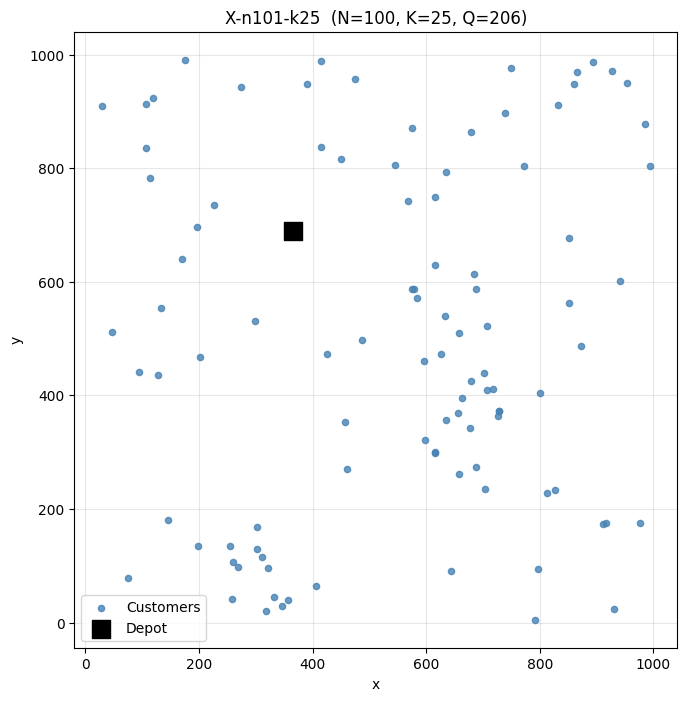

In [11]:
executer = NSGA2Executer(instances_folder="data/")

# Build the benchmark to get the instance for plotting; the executer
# will rebuild its own when running.
benchmark = executer._build_benchmark(INSTANCE_NAME)
instance = benchmark.instance

plot_instance(instance)
plt.show()

## 3. Single run

One execution of NSGA-II with a fixed seed. The result is the final non-dominated archive (an approximation of the Pareto front).

In [12]:
nsga2 = executer.run_single_experiment(
    INSTANCE_NAME,
    seed=0,
    pop_size=POP_SIZE,
    max_generations=MAX_GENERATIONS,
)

print(f"Pareto front size:    {len(nsga2.final_archive)}")
print(f"Generations executed: {nsga2.num_generations}")
print(f"Total evaluations:    {nsga2.num_evaluations}")

Pareto front size:    14
Generations executed: 100
Total evaluations:    5050


## 4. Visualize results

### 4.1 Pareto front

Each point is a non-dominated trade-off between total distance (f1) and demand imbalance (f2).

In [13]:
# plot_pareto_front(nsga2.final_archive)
# plt.show()

### 4.2 Routes for the minimum-distance solution

Decode and plot the front solution with the smallest f1. Sanity-check that all customers are visited and routes start/end at the depot.

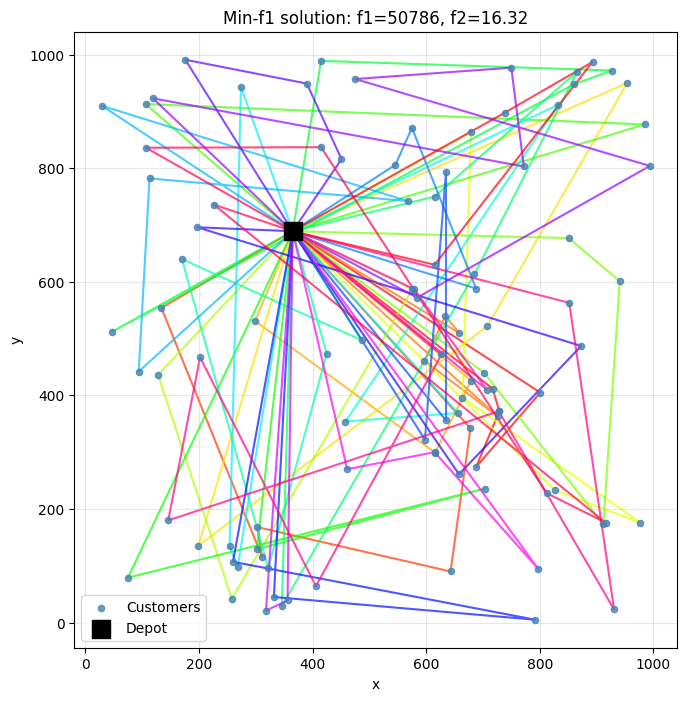

In [14]:
best_f1 = min(nsga2.final_archive, key=lambda ind: ind.fitness.values[0])
routes = benchmark.decoder.decode(best_f1.candidate)

ax = plot_instance(instance)
plot_routes(routes, instance, ax=ax)
ax.set_title(
    f"Min-f1 solution: f1={best_f1.fitness.values[0]:.0f}, "
    f"f2={best_f1.fitness.values[1]:.2f}"
)
plt.show()

### 4.3 Convergence

Best/median f1 per generation, with min-max shading. f1 is used here as a proxy; Layer 6 will add a hypervolume-based convergence plot (`plot_hv_convergence`).

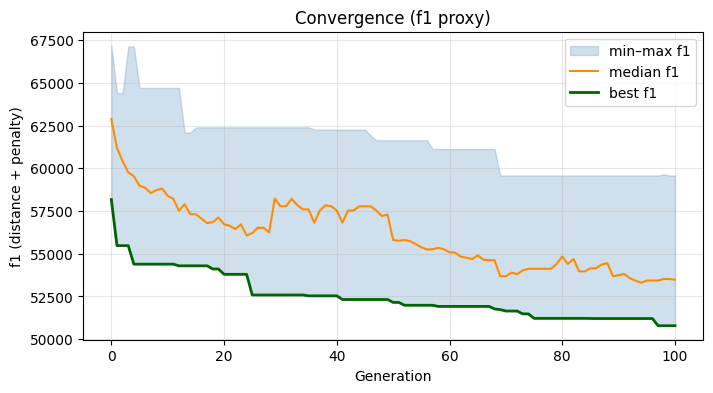

In [15]:
plot_convergence(nsga2.history)
plt.show()

## 5. Repeated runs

Run NSGA-II with `n_repeat` different seeds and aggregate the results into a long-format DataFrame: one row per Pareto solution per run.

In [16]:
df = executer.run_repeated_experiment(
    INSTANCE_NAME,
    n_repeat=N_REPEAT_DEMO,
    pop_size=POP_SIZE,
    max_generations=MAX_GENERATIONS,
)

df.head()

X-n101-k25.vrp - run 1/10


X-n101-k25.vrp - run 2/10
X-n101-k25.vrp - run 3/10
X-n101-k25.vrp - run 4/10
X-n101-k25.vrp - run 5/10
X-n101-k25.vrp - run 6/10
X-n101-k25.vrp - run 7/10
X-n101-k25.vrp - run 8/10
X-n101-k25.vrp - run 9/10
X-n101-k25.vrp - run 10/10


,run,solution_idx,f1,f2,n_evaluations,n_generations
0,0,0,58684.846261,9.632733,5050,100
1,0,1,53757.327425,13.306963,5050,100
2,0,2,51976.112404,15.856620,5050,100
3,0,3,56367.388113,10.522267,5050,100
4,0,4,52357.403241,14.474247,5050,100


### 5.1 Summary across runs

In [17]:
front_sizes = df.groupby("run").size()
print(
    f"Front size (mean / std / min / max): "
    f"{front_sizes.mean():.1f} / {front_sizes.std():.1f} / "
    f"{front_sizes.min()} / {front_sizes.max()}"
)
print(f"Best f1 across all runs: {df['f1'].min():.2f}")
print(f"Best f2 across all runs: {df['f2'].min():.4f}")
print(f"Total runs: {df['run'].nunique()}")

Front size (mean / std / min / max): 16.3 / 4.0 / 10 / 24
Best f1 across all runs: 46850.86
Best f2 across all runs: 7.8969
Total runs: 10


## 6. Run all experiments (demo)

Demonstrates `run_all_experiments` end-to-end: iterates instances, runs each `n_repeat` times, and writes one CSV per instance. Restricted to a single instance and small `n_repeat` here so the cell finishes quickly. The full grid is in Layer 5.

Output goes to `tmp/nsga2_demo/` so it does not pollute the committed `experiments/` folder.

In [18]:
demo_executer = NSGA2Executer(instances_folder="data/")
demo_executer.instances = [INSTANCE_NAME]  # restrict for demo speed

demo_executer.run_all_experiments(
    "tmp/nsga2_demo/",
    n_repeat=3,
    overwrite=True,
    pop_size=POP_SIZE,
    max_generations=MAX_GENERATIONS,
)

Running experiments for X-n101-k25.vrp
X-n101-k25.vrp - run 1/3
X-n101-k25.vrp - run 2/3
X-n101-k25.vrp - run 3/3
Saved to tmp/nsga2_demo/X-n101-k25.csv
